# Milestone 3 - Modelação e Avaliação (Objetivo 2: Índice de Risco de Attrition)

Neste notebook é desenvolvido um índice de risco de abandono (`Attrition`), com base nas probabilidades previstas pelo modelo de Regressão Logística (com escalonamento de variáveis via *StandardScaler*), construído especificamente para garantir interpretabilidade e estabilidade probabilística.

Este trabalho enquadra-se nas fases de *Modelling* e *Evaluation* da metodologia CRISP-DM, dando continuidade à etapa anterior (**Objetivo 1**), onde foi estabelecida a *Baseline* preditiva do projeto.

O objetivo principal deste notebook consiste em construir um índice de risco de *attrition*, que permita segmentar os colaboradores em diferentes níveis de risco, com base na probabilidade estimada de abandono, até à data definida para a Milestone 3.

Para esse efeito, os colaboradores são classificados nas seguintes categorias:

- **Baixo risco**: probabilidade de attrition inferior a 30%;
- **Risco médio**: probabilidade entre 30% e 60%;
- **Alto risco**: probabilidade superior a 60%.

Após a obtenção das probabilidades através do modelo selecionado, esta fase tem como propósito:

- Utilizar as probabilidades previstas (`predict_proba`) para estimar o risco individual de abandono de cada colaborador;
- Construir uma variável categórica de risco com base nos limiares definidos;
- Analisar visualmente a distribuição dos colaboradores pelos diferentes níveis de risco(recorrendo a Histogramas e Boxplots);
- Comparar as características médias dos grupos identificados, de forma a compreender o perfil sociodemográfico e laboral associado a cada nível de risco;
- Avaliar a coerência entre o índice de risco construído e a variável alvo real (`Attrition`);
- Interpretar os resultados numa perspetiva de negócio, identificando implicações práticas para a retenção de talento.

A definição dos limiares de segmentação foi orientada por critérios interpretativos e operacionais, permitindo transformar probabilidades contínuas em categorias acionáveis para suporte à decisão.

Este índice de risco constitui uma ferramenta de apoio à gestão, permitindo priorizar ações preventivas de retenção e desenvolver estratégias diferenciadas para colaboradores com diferentes níveis de risco de abandono.

**Autores:** Luís Figueira, Martim Ferreira e Mateus Afonso

# Índice de Risco - Regressão Logística
Modelo de Regressão Logística com StandardScaler e classificação de risco.

In [1]:
# 1. IMPORTAÇÕES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay,
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [2]:
# 2. CARREGAMENTO DO DATASET

#url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
#df = pd.read_csv(url)
#print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

In [3]:
# 3. PREPARAÇÃO DAS FEATURES

#cols_remover = ["Attrition", "OverTime", "Gender",
#                "BusinessTravel", "Department", "EducationField",
#                "JobRole", "MaritalStatus"]

#cols_remover = [c for c in cols_remover if c in df.columns]
#df_model = df.drop(columns=cols_remover)

#TARGET = "Attrition_bin"
#X = df_model.drop(columns=[TARGET])
#y = df_model[TARGET]
#X = X.select_dtypes(include=[np.number])

#print(f"Features utilizadas: {X.shape[1]}")

In [4]:
# 4. DIVISÃO TREINO / TESTE — Gerar
#import os
#import zipfile
#from IPython.display import FileLink, display

#treino_path = "data/processed/Objetivo2/treino"
#teste_path  = "data/processed/Objetivo2/teste"

# 80% treino, 20% teste
# stratify=y — garante a mesma proporção de Yes/No em treino e teste
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)

# Criar as pastas e guardar os splits
#os.makedirs(treino_path, exist_ok=True)
#os.makedirs(teste_path, exist_ok=True)
#X_train.to_csv(f"{treino_path}/X_train.csv", index=False)
#y_train.to_csv(f"{treino_path}/y_train.csv", index=False)
#X_test.to_csv(f"{teste_path}/X_test.csv", index=False)
#y_test.to_csv(f"{teste_path}/y_test.csv", index=False)

# Criar ZIP com a estrutura de pastas completa
#zip_path = "data/processed/Objetivo2/splits.zip"
#with zipfile.ZipFile(zip_path, "w") as zipf:
#    zipf.write(f"{treino_path}/X_train.csv", "treino/X_train.csv")
#    zipf.write(f"{treino_path}/y_train.csv", "treino/y_train.csv")
#    zipf.write(f"{teste_path}/X_test.csv",   "teste/X_test.csv")
#    zipf.write(f"{teste_path}/y_test.csv",   "teste/y_test.csv")

#print("Splits gerados! :")
#display(FileLink(zip_path))

In [5]:
# 4. DIVISÃO TREINO / TESTE — CARREGAR DO GITHUB
base_treino = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo2/treino"
base_teste  = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo2/teste"

# Carregar diretamente do GitHub
X_train = pd.read_csv(f"{base_treino}/X_train.csv")
y_train = pd.read_csv(f"{base_treino}/y_train.csv").squeeze()
X_test  = pd.read_csv(f"{base_teste}/X_test.csv")
y_test  = pd.read_csv(f"{base_teste}/y_test.csv").squeeze()

print(f"Treino: {X_train.shape[0]} obs | Teste: {X_test.shape[0]} obs")

Treino: 1176 obs | Teste: 294 obs


In [6]:
# 5. TREINO — REGRESSÃO LOGÍSTICA

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression())
])

pipeline.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [7]:
# 6. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [8]:
# 6.1 TREINO
r_treino = avaliar_modelo(pipeline, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.6519
  Precision: 0.8175
  Recall:    0.5421
  AUC-ROC:   0.8819

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.54      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.76      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [9]:
# 6.2 TESTE
r_teste = avaliar_modelo(pipeline, X_test, y_test, "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.4595
  Precision: 0.6296
  Recall:    0.3617
  AUC-ROC:   0.8170

              precision    recall  f1-score   support

  Permaneceu       0.89      0.96      0.92       247
        Saiu       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



In [10]:
# 7. COMPARAÇÃO TREINO vs TESTE

print("===== COMPARAÇÃO TREINO vs TESTE =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*42}")
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = r_treino[metrica]
    val_teste  = r_teste[metrica]
    diff       = val_treino - val_teste
    nome       = metrica.upper() if metrica != "acc" else "Accuracy"
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

diff_f1 = r_treino["f1"] - r_teste["f1"]
if diff_f1 > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE =====
  Métrica         Treino     Teste   Diferença
  ------------------------------------------
  Accuracy        0.9065    0.8639     +0.0425
  PRECISION       0.8175    0.6296     +0.1878
  RECALL          0.5421    0.3617     +0.1804
  F1              0.6519    0.4595     +0.1924
  AUC             0.8819    0.8170     +0.0649
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


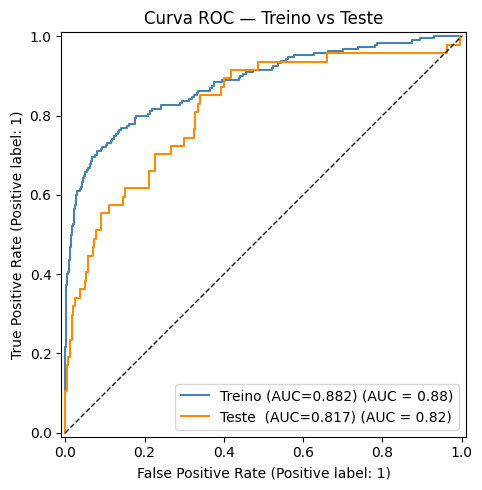

In [11]:
# 8. CURVAS ROC SOBREPOSTAS

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    r_treino["y"], r_treino["y_proba"],
    name=f"Treino (AUC={r_treino['auc']:.3f})", ax=ax, color="steelblue"
)
RocCurveDisplay.from_predictions(
    r_teste["y"], r_teste["y_proba"],
    name=f"Teste  (AUC={r_teste['auc']:.3f})", ax=ax, color="darkorange"
)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Treino vs Teste")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# 9. GERAR PROBABILIDADES DE SAÍDA (dataset completo)
url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features que fizeste no início
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"])
X_completo = X_completo.select_dtypes(include=[np.number])

df_risco = df_completo.copy()
df_risco["prob_saida"] = pipeline.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco)} colaboradores.")
print(df_risco["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores.
count    1470.0000
mean        0.1591
std         0.2222
min         0.0000
25%         0.0132
50%         0.0598
75%         0.2057
90%         0.5180
max         0.9932
Name: prob_saida, dtype: float64


In [13]:
# 10. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

df_risco["nivel_risco"] = df_risco["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem    = df_risco["nivel_risco"].value_counts()
percentagem = df_risco["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUICAO DAS CATEGORIAS DE RISCO =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


===== DISTRIBUICAO DAS CATEGORIAS DE RISCO =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo           1217         82.8%
  Medio            147         10.0%
  Alto             106          7.2%


In [14]:
# 11. ANÁLISE POR CATEGORIA DE RISCO

cols_analise = ["prob_saida", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco.columns:
        cols_analise.append(col)

print("\n===== PERFIL MEDIO POR CATEGORIA DE RISCO =====")
perfil = df_risco.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil)


===== PERFIL MEDIO POR CATEGORIA DE RISCO =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.071,0.065,37.969,6977.157,2.177,12.175,0.214,2.217,7.604
Medio,0.441,0.449,32.571,4438.803,1.578,7.605,0.605,1.993,4.844
Alto,0.782,0.868,30.962,3920.802,1.443,6.094,0.632,1.811,3.170


In [15]:
# 12. TOP 20 COLABORADORES COM MAIOR RISCO

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco.columns:
        cols_top.append(col)

top20 = df_risco.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAIDA =====")
display(top20)


===== TOP 20 — MAIOR PROBABILIDADE DE SAIDA =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.993184,Alto,1,26,2340,1,1
1,0.992612,Alto,1,25,1118,1,1
2,0.984904,Alto,1,24,3172,1,1
3,0.981745,Alto,1,18,1878,1,1
4,0.980088,Alto,1,21,2174,1,1
5,0.978946,Alto,1,32,2795,1,1
6,0.960832,Alto,1,19,1675,1,1
7,0.953581,Alto,1,19,2325,1,0
8,0.951764,Alto,1,19,2121,1,1
9,0.950460,Alto,1,27,2863,1,0


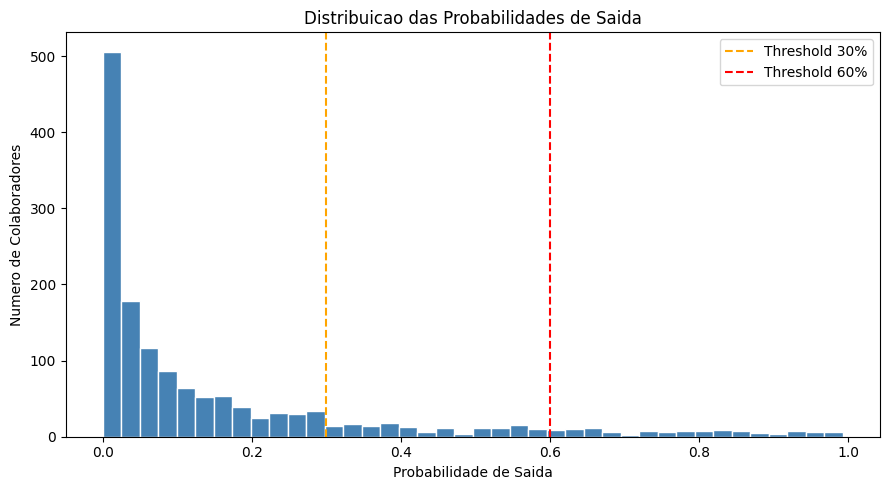

In [16]:
# 13. VISUALIZAÇÕES DO ÍNDICE DE RISCO

# 13.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_risco["prob_saida"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")
ax.set_xlabel("Probabilidade de Saida")
ax.set_ylabel("Numero de Colaboradores")
ax.set_title("Distribuicao das Probabilidades de Saida")
ax.legend()
plt.tight_layout()
plt.savefig("distribuicao_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()

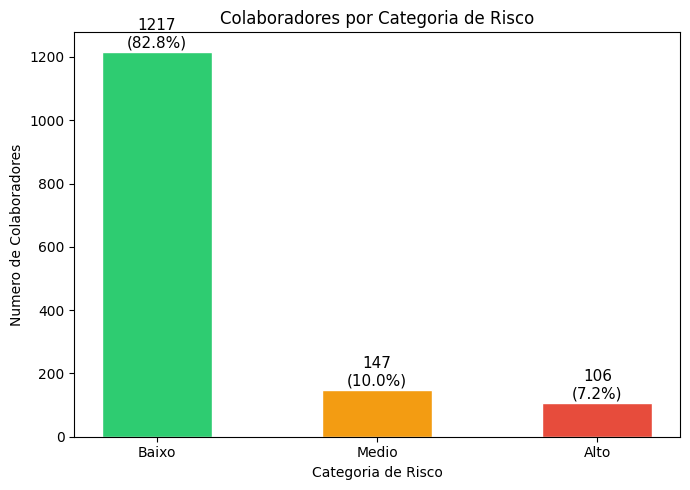

In [17]:
# 13.2 Contagem por categoria
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}

fig, ax = plt.subplots(figsize=(7, 5))
vals = [contagem.get(c, 0) for c in ORDEM]
bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)
for bar, cat in zip(bars, ORDEM):
    n   = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Numero de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco")
plt.tight_layout()
plt.savefig("categorias_risco.png", dpi=150, bbox_inches="tight")
plt.show()

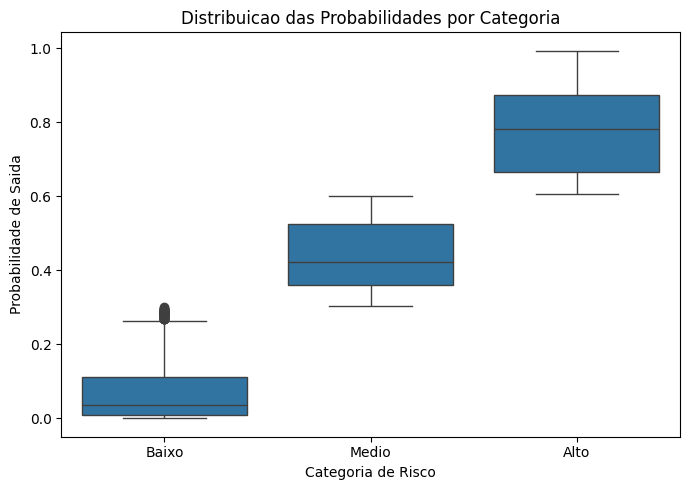

In [18]:
# 13.3 Boxplot por categoria
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_risco, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax)
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saida")
ax.set_title("Distribuicao das Probabilidades por Categoria")
plt.tight_layout()
plt.savefig("boxplot_risco.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# 14. RESUMO FINAL

print("=" * 55)
print("RESUMO — Baseline")
print("=" * 55)
print(f"  Modelo:         Regressao Logistica (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {r_treino[metrica]:>8.4f}  {r_teste[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem.get('Alto', 0)} colaboradores")
print("=" * 55)

RESUMO — Baseline
  Modelo:         Regressao Logistica (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.9065    0.8639
  Precision       0.8175    0.6296
  Recall          0.5421    0.3617
  F1-Score        0.6519    0.4595
  AUC-ROC         0.8819    0.8170

  Baixo risco:    prob < 30%  -> 1217 colaboradores
  Risco medio:    30% - 60%   -> 147 colaboradores
  Alto risco:     prob > 60%  -> 106 colaboradores


#  Treino e Avaliação Comparativa do Desempenho de Modelos Candidatos


## Índice de Risco - Naive Bayes
Modelo Naive Bayes com StandardScaler e classificação de risco.

In [20]:
# 15. TREINO — NAIVE BAYES
pipeline_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

pipeline_nb.fit(X_train, y_train)
print("Modelo Naive Bayes treinado.")

Modelo Naive Bayes treinado.


In [21]:
# 16. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (NAIVE BAYES)

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [22]:
# 16.1 TREINO
resultados_treino_nb = avaliar_modelo(pipeline_nb, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.4294
  Precision: 0.3004
  Recall:    0.7526
  AUC-ROC:   0.7768

              precision    recall  f1-score   support

  Permaneceu       0.93      0.66      0.77       986
        Saiu       0.30      0.75      0.43       190

    accuracy                           0.68      1176
   macro avg       0.62      0.71      0.60      1176
weighted avg       0.83      0.68      0.72      1176



In [23]:
# 16.2 TESTE
resultados_teste_nb  = avaliar_modelo(pipeline_nb, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.3681
  Precision: 0.2586
  Recall:    0.6383
  AUC-ROC:   0.6831

              precision    recall  f1-score   support

  Permaneceu       0.90      0.65      0.76       247
        Saiu       0.26      0.64      0.37        47

    accuracy                           0.65       294
   macro avg       0.58      0.65      0.56       294
weighted avg       0.80      0.65      0.70       294



In [24]:
# 17. COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES)

print("===== COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_nb[metrica]
    val_teste  = resultados_teste_nb[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_nb = resultados_treino_nb["f1"] - resultados_teste_nb["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_nb > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.6769    0.6497     +0.0272
  PRECISION       0.3004    0.2586     +0.0418
  RECALL          0.7526    0.6383     +0.1143
  F1              0.4294    0.3681     +0.0613
  AUC             0.7768    0.6831     +0.0938

  --> Sem sinais evidentes de overfitting.


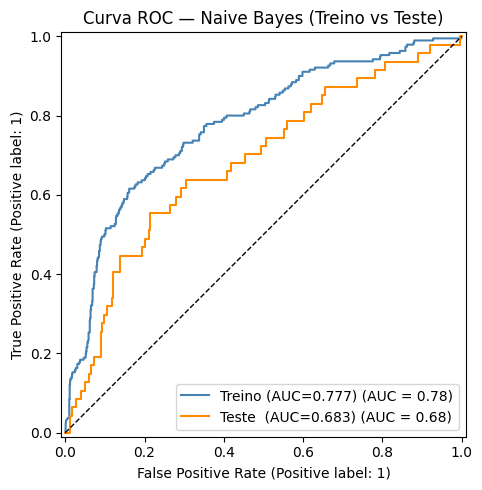

In [25]:
# 18. CURVAS ROC SOBREPOSTAS (NAIVE BAYES)

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino
RocCurveDisplay.from_predictions(
    resultados_treino_nb["y"], resultados_treino_nb["y_proba"],
    name=f"Treino (AUC={resultados_treino_nb['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste
RocCurveDisplay.from_predictions(
    resultados_teste_nb["y"], resultados_teste_nb["y_proba"],
    name=f"Teste  (AUC={resultados_teste_nb['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — Naive Bayes (Treino vs Teste)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste_nb.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# 19. GERAR PROBABILIDADES DE SAÍDA (dataset completo - NAIVE BAYES)

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Adicionei errors='ignore' para evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_nb para não sobrescrever o teu trabalho da Regressão Logística
df_risco_nb = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do Naive Bayes
df_risco_nb["prob_saida"] = pipeline_nb.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_nb)} colaboradores (Naive Bayes).")
print(df_risco_nb["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (Naive Bayes).
count    1470.0000
mean        0.3936
std         0.4290
min         0.0000
25%         0.0000
50%         0.1272
75%         0.9141
90%         0.9984
max         1.0000
Name: prob_saida, dtype: float64


In [27]:
# 20. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (NAIVE BAYES)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

# Aplicar a função ao DataFrame do Naive Bayes
df_risco_nb["nivel_risco"] = df_risco_nb["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem_nb    = df_risco_nb["nivel_risco"].value_counts()
percentagem_nb = df_risco_nb["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUICAO DAS CATEGORIAS DE RISCO (NAIVE BAYES) =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem_nb.get(cat, 0)
    pct = percentagem_nb.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


===== DISTRIBUICAO DAS CATEGORIAS DE RISCO (NAIVE BAYES) =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo            811         55.2%
  Medio            105          7.1%
  Alto             554         37.7%


In [28]:
# 21. ANÁLISE POR CATEGORIA DE RISCO (NAIVE BAYES)

cols_analise = ["prob_saida", "Attrition_bin"]
# Adicionamos as variáveis de negócio para ver a "cara" de cada nível de risco
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears", 
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco_nb.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (NAIVE BAYES) =====")
perfil_nb = df_risco_nb.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil_nb)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (NAIVE BAYES) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.029,0.072,39.624,8597.938,2.580,14.649,0.249,2.243,9.238
Medio,0.455,0.095,36.343,4114.543,1.486,9.267,0.276,2.171,6.219
Alto,0.916,0.305,33.081,3888.726,1.419,6.729,0.334,2.051,3.894


In [29]:
# 22. TOP 20 COLABORADORES COM MAIOR RISCO (NAIVE BAYES)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_nb.columns:
        cols_top.append(col)

top20_nb = df_risco_nb.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (NAIVE BAYES) =====")
display(top20_nb)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (NAIVE BAYES) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,1.0,Alto,1,24,1555,1,0
1,1.0,Alto,0,36,3886,2,0
2,1.0,Alto,1,27,2863,1,0
3,1.0,Alto,0,31,6410,2,0
4,1.0,Alto,1,31,2956,1,0
5,1.0,Alto,1,29,2335,1,1
6,1.0,Alto,1,37,2073,1,1
7,1.0,Alto,1,30,2180,1,0
8,1.0,Alto,0,25,2187,1,0
9,1.0,Alto,0,38,6077,2,0


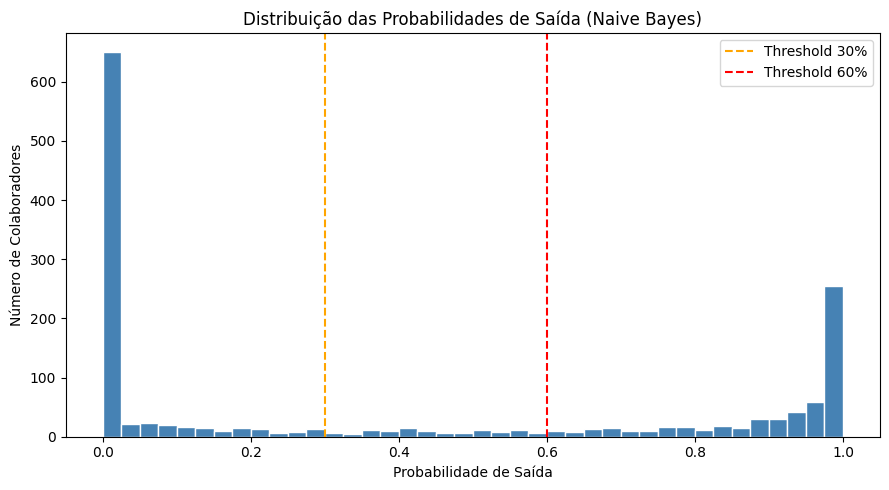

In [30]:
# 23. VISUALIZAÇÕES DO ÍNDICE DE RISCO (NAIVE BAYES)
import matplotlib.pyplot as plt

# 23.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

# Usar o df_risco_nb do nosso Naive Bayes
ax.hist(df_risco_nb["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Manter as linhas dos limiares
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (Naive Bayes)")
ax.legend()

plt.tight_layout()
# Guardar com um nome diferente para não sobrescrever a Baseline
plt.savefig("distribuicao_probabilidades_nb.png", dpi=150, bbox_inches="tight")
plt.show()

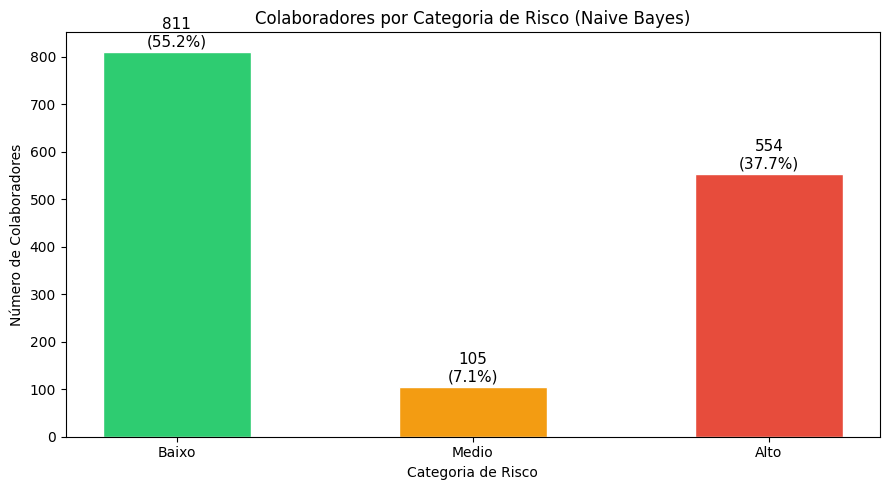

In [31]:
# 23.2 Contagem por categoria (NAIVE BAYES)
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}

fig, ax = plt.subplots(figsize=(9, 5))
# Ir buscar os valores às contagens do Naive Bayes
vals = [contagem_nb.get(c, 0) for c in ORDEM]

bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)

for bar, cat in zip(bars, ORDEM):
    n   = contagem_nb.get(cat, 0)
    pct = percentagem_nb.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5, # Ajuste da altura do texto
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (Naive Bayes)")
plt.tight_layout()

# Guardar com um nome diferente para preservar a imagem da Baseline
plt.savefig("categorias_risco_nb.png", dpi=150, bbox_inches="tight")
plt.show()

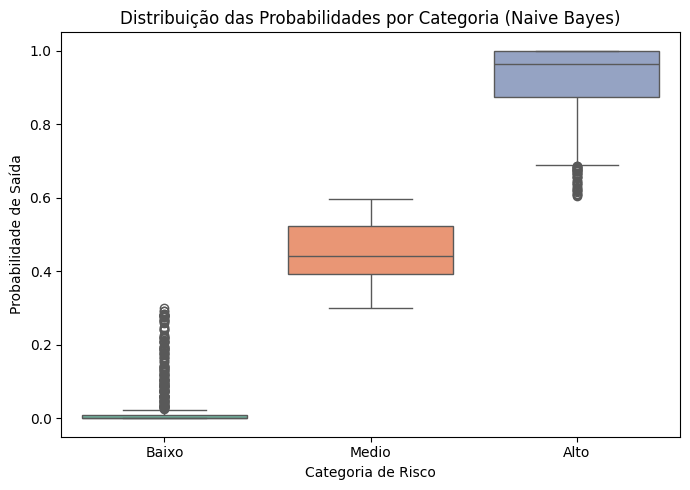

In [32]:
# 23.3 Boxplot por categoria (NAIVE BAYES)
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_risco_nb, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax, palette="Set2")
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (Naive Bayes)")
plt.tight_layout()
plt.savefig("boxplot_risco_nb.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# 24. RESUMO FINAL (NAIVE BAYES)

print("=" * 55)
print("RESUMO — Naive Bayes")
print("=" * 55)
print(f"  Modelo:         Naive Bayes (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_nb)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {resultados_treino_nb[metrica]:>8.4f}  {resultados_teste_nb[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem_nb.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem_nb.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem_nb.get('Alto', 0)} colaboradores")
print("=" * 55)

RESUMO — Naive Bayes
  Modelo:         Naive Bayes (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.6769    0.6497
  Precision       0.3004    0.2586
  Recall          0.7526    0.6383
  F1-Score        0.4294    0.3681
  AUC-ROC         0.7768    0.6831

  Baixo risco:    prob < 30%  -> 811 colaboradores
  Risco medio:    30% - 60%   -> 105 colaboradores
  Alto risco:     prob > 60%  -> 554 colaboradores
